In [1]:
#Import Libraries need for project
import matplotlib.pyplot as plt 
import cv2
import os 
import numpy as np
import random

In [2]:
#Rename image_name 
import os
from pathlib import Path

def rename_images(root_dir):
    """
    Rename images in each subfolder as:
    foldername_1.jpg, foldername_2.jpg, ...
    """

    root_dir = Path(root_dir)

    # loop through each class folder
    for folder in root_dir.iterdir():

        if folder.is_dir():

            folder_name = folder.name

            images = list(folder.glob("*.*"))  # all files

            images.sort()  # keep consistent order

            count = 1

            for img_path in images:

                # keep only image files
                if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
                    continue

                new_name = f"{folder_name}_{count}{img_path.suffix.lower()}"
                new_path = folder / new_name

                os.rename(img_path, new_path)

                print(f"{img_path.name} -> {new_name}")

                count += 1

In [3]:
rename_images("Dataset/train")

10 things to know about Alan Turing _ Bletchley Park (1).png -> alan _turing_1.png
10 things to know about Alan Turing _ Bletchley Park.png -> alan _turing_2.png
16 Alan turing Images_ PICRYL - Public Domain Media Search Engine Public  Domain Search.jpg -> alan _turing_3.jpg
268 Alan Turing Photos et images haute résolution - Getty Images (1).jpg -> alan _turing_4.jpg
268 Alan Turing Photos et images haute résolution - Getty Images.jpg -> alan _turing_5.jpg
8 idées reçues sur Alan Turing, vainqueur de l'Enigma nazie et père de  l'informatique - Historia.jpg -> alan _turing_6.jpg
A Tribute to Alan Turing, the father of Computer science and hero of WWII  Cryptography - by.jpg -> alan _turing_7.jpg
About Alan Turing _ The Turing Digital Archive.jpg -> alan _turing_8.jpg
Alan Mathison Turing (1912-1954), un mathématicien britannique, est  largement considéré comme le père de l'informatique théorique et de  l'intelligence artificielle. Pendant .jpg -> alan _turing_9.jpg
Alan Mathison Turing

In [4]:
rename_images("Dataset/test")

1.jpg -> alan_turing_1.jpg
2.jpg -> alan_turing_2.jpg
3.jpg -> alan_turing_3.jpg
Alan Turing - People in AI - AI Blog.jpg -> alan_turing_4.jpg
Alan Turing — Wikipédia.jpg -> alan_turing_5.jpg
Alan Turing, The Enigma Painting by Esoterica Art Agency - Fine Art America.jpg -> alan_turing_6.jpg
Alan Turing.jpg -> alan_turing_7.jpg
Biographie d'Alan Turing (23 juin 1912 [Londres] - 8 juin 1954).jpg -> alan_turing_8.jpg
British scientist ALAN turing_(1912-1954, one of the people responsible for  the creation of computers, colorized by me.jpg -> alan_turing_9.jpg
Codebreaker Alan Turing's Secret Notebook Goes on the Block _ Observer.jpg -> alan_turing_10.jpg
Fichier_Alan Turing Aged 16.jpg — Wikipédia.jpg -> alan_turing_11.jpg
Image of Portrait d'Alan Mathison Turing, (1912 - 54) (photo n&b).jpg -> alan_turing_12.jpg
Non, le test de Turing n'a pas été passé par Eugene Goostman_.jpg -> alan_turing_13.jpg
NPG x27078; Alan Turing - Portrait - National Portrait Gallery.jpg -> alan_turing_14.jpg


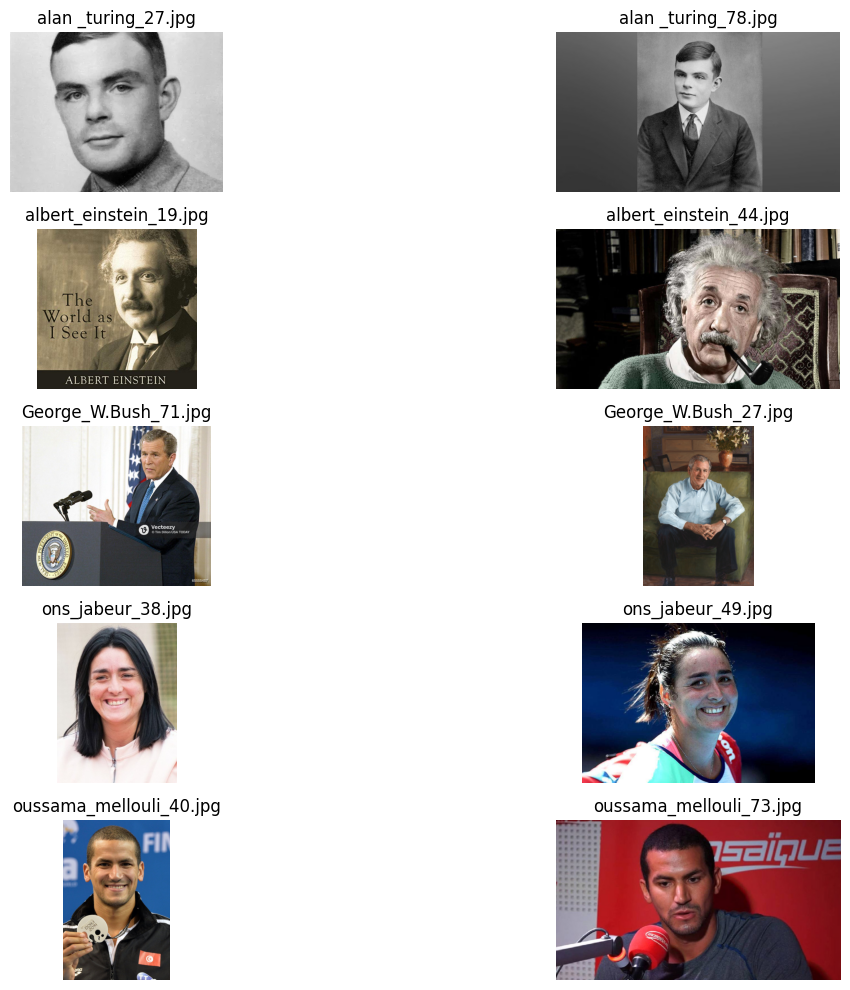

In [31]:
#Visualize image before face extration 

path = r"Dataset\train"

plt.figure(figsize=(15, 10))

plot_num = 1

for folder in os.listdir(path):

    folder_path = os.path.join(path, folder)

    imgs = os.listdir(folder_path)

    sample_imgs = random.sample(imgs, 2)

    for img_name in sample_imgs:

        img_path = os.path.join(folder_path, img_name)

        img = plt.imread(img_path)

        plt.subplot(len(os.listdir(path)), 2, plot_num)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

        plot_num += 1

plt.tight_layout()
plt.show()


   

In [2]:
#Import haacascade model for face extraction 
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

In [5]:
#function 'extract_face' that takes as input the image name and the desired output image size and 
#loads the HAAR model to perform face detection task 
def extract_face(image_path, size=(160,160)):

    import os

    if not os.path.exists(image_path):
        print("File does not exist:", image_path)
        return None

    img = cv2.imread(image_path)

    if img is None:
        print("OpenCV failed to load image:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=2,
        minSize=(10,10)
    )

    if len(faces) == 0:
        print("No face found")
        return None

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    face = gray[y:y+h, x:x+w]
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, size)
    
    return face

In [8]:
#lOAD FACES FROM DIRECTORY NAME 
import os
import cv2

def load_face(dir_name, dataset_type):
    faces = []

    person_name = os.path.basename(dir_name)

    output_dir = os.path.join(
        "extracted_faces",
        dataset_type,
        person_name
    )

    os.makedirs(output_dir, exist_ok=True)

    for i, filename in enumerate(os.listdir(dir_name)):

        path = os.path.join(dir_name, filename)

        face = extract_face(path)
        

        if face is not None:
            faces.append(face)

            save_path = os.path.join(
                output_dir,
                f"{person_name}_{i}.jpg"
            )

            cv2.imwrite(save_path, face)

    return faces

In [12]:
#lOAD FACES FROM DIRECTORY NAME 
import os

def load_faces(dir_name):
    faces = []

    for filename in os.listdir(dir_name):
        path = os.path.join(dir_name, filename)

        face = extract_face(path)
        if face is not None:
            faces.append(face)

    return faces

In [9]:
test_path = r"Dataset\test"

for folder in os.listdir(test_path):
    folder_path = os.path.join(test_path, folder)

    load_faces(folder_path, "test")

In [10]:
train_path = r"Dataset\train"

for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)

    load_faces(folder_path, "train")

No face found
OpenCV failed to load image: Dataset\train\George_W.Bush\George W. Bush'_ Stunning documentary on worst American president (until  now) – People's World.gif
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found
No face found


In [24]:
#Function 'load_dataset' that takes the parent directory name and loops through its child directory to apply the load faces function. 
# and assign to them the corresponding label which is the child directory name
def load_dataset(parent_dir):
    X=[]
    y=[]
    for subdir in os.listdir(parent_dir):
        path=os.path.join(parent_dir,subdir)
        for img in os.listdir(path):
            image=cv2.imread(os.path.join(path,img))
            image=cv2.resize(image,(224,224))
            X.append(image)
            y.append(subdir)
        
    return X,y

In [25]:
#Execution of function 'Load_dataset on the train set as well as on the test set
X_train,y_train = load_dataset(r"extracted_faces\train")
X_test,y_test = load_dataset(r"extracted_faces\test")

In [27]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

In [28]:
X_train.shape

(336, 224, 224, 3)

In [29]:
X_test.shape

(90, 224, 224, 3)

In [30]:
#Save the generated images for both sets into the same compressed ‘.npz’ file.
np.savez_compressed(
    "final_dataset.npz",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

In [31]:
data = np.load("final_dataset.npz", allow_pickle=True)

print(data.files)

['X_train', 'y_train', 'X_test', 'y_test']


In [32]:
data = np.load("final_dataset.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

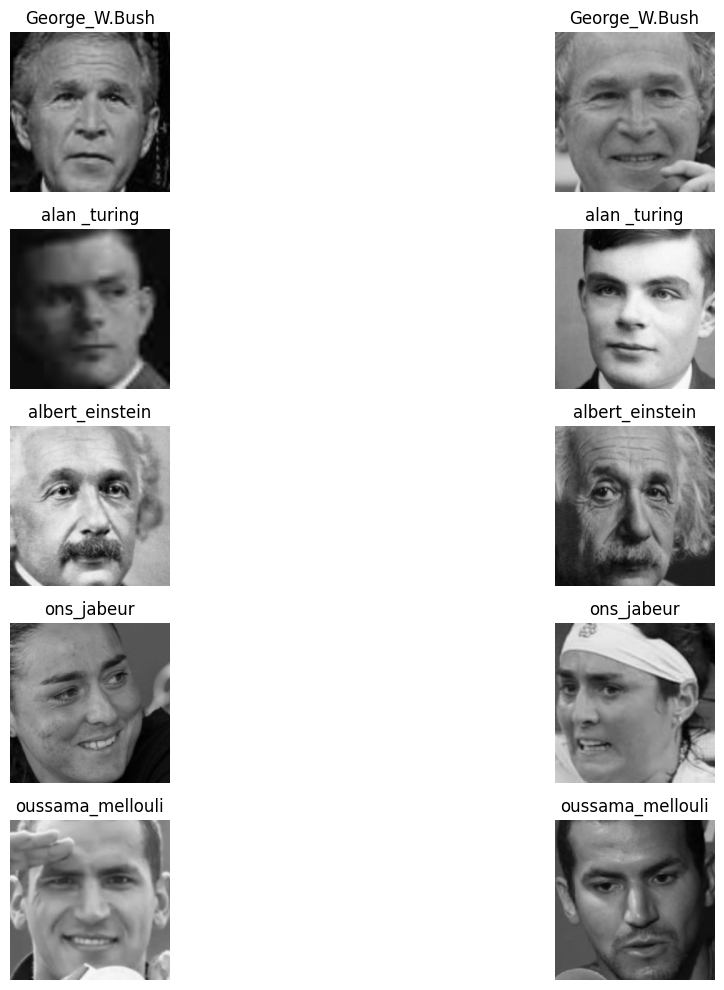

In [33]:
#Visualize Image after face extraction

unique_labels = np.unique(y_train)

plt.figure(figsize=(15, 10))

plot_num = 1

for label in unique_labels:

    # Get all indices for this person
    indices = np.where(y_train == label)[0]

    # Select 2 random faces
    sample_indices = random.sample(list(indices), min(2, len(indices)))

    for idx in sample_indices:

        plt.subplot(len(unique_labels), 2, plot_num)

        if len(X_train[idx].shape) == 2:
            plt.imshow(X_train[idx], cmap="gray")
        else:
            plt.imshow(X_train[idx])

        plt.title(label)
        plt.axis("off")

        plot_num += 1

plt.tight_layout()
plt.show()

In [36]:
image=extract_face("download.jpg")
np

In [42]:
np.array(image).shape

(224, 224, 3)

In [41]:
image=cv2.resize(image,(224,224))

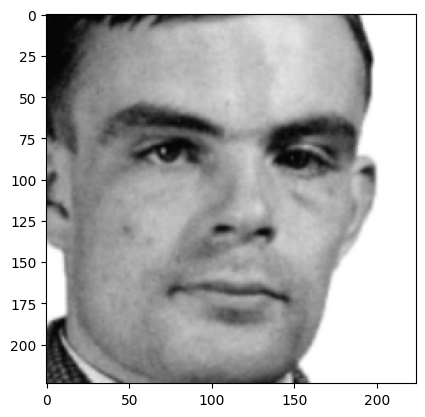

In [43]:
plt.imshow(image)

In [44]:
cv2.imwrite("face.jpg", image)

True